In [1]:
import pandas as pd
import numpy as np
import sys
import gseapy as gp
from typing import Dict, Optional, Tuple, Any, List
import math
import json
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import warnings
from scipy.stats import spearmanr
import seaborn as sns

sys.path.append("/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/")
from SynOmics.processing.metadata import MetaData
dataset_dict = {}
original_data = pd.read_csv("Data/original_data.csv", index_col = 0)
dataset_dict["Origin"] = original_data
seed = 42
syn_datas = [f"avatarsk5_{seed}",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]
for i, tool in enumerate(syn_datas):
    syn_df = pd.read_csv(f"Data/{syn_datas[i]}.csv", index_col = 0)
    dataset_dict[tool] = syn_df


mapped_dataset = {}
with open("ssGSEA/mapping_genes.json", "r") as f:
    genes_mapping = json.load(f)
    
abnormal_counts = []
nan_counts = []
for k, v in genes_mapping.items():
    if isinstance(v[0], float) and math.isnan(v[0]):
        nan_counts.append([k, v])
        abnormal_counts.append([k,v])
    elif len(v) > 1 and isinstance(v[0], str):
        abnormal_counts.append([k,v])
        genes_mapping[k]=[v[0]]
            
def ensembl_to_hugo(col, mapping):
    ensembl_id = col.split('.')[0]  # Remove version
    hugo = mapping.get(ensembl_id, [col])  # fallback: leave as is if not found
    return str(hugo[0])
    

for k in nan_counts:
    genes_mapping.pop(k[0], None)

genes_cols = []
for col in original_data.columns:
    if col.startswith("ENSG"):
        genes_cols.append(col)
        
symbols_dataset_dict = {}
for tool, data in dataset_dict.items():
    genes_exp_df = data[genes_cols]
    # Rename column
    genes_exp_df_mapped = genes_exp_df.copy()
    genes_exp_df_mapped.columns = [ensembl_to_hugo(col, genes_mapping) for col in genes_exp_df_mapped.columns]
    
    drop_cols = [col for col in genes_exp_df_mapped.columns if col.startswith("ENSG")]
    genes_exp_df_mapped = genes_exp_df_mapped.drop(columns = drop_cols)
    
    genes_exp_df_mapped_t =genes_exp_df_mapped.T.reset_index()
    genes_exp_df_mapped_t.columns.values[0] = 'Gene'
    
    #Avaraging duplicated genes
    genes_exp_df_mapped_t_grouped = genes_exp_df_mapped_t.groupby("Gene", as_index=False).mean()
    symbols_dataset_dict[tool] = genes_exp_df_mapped_t_grouped

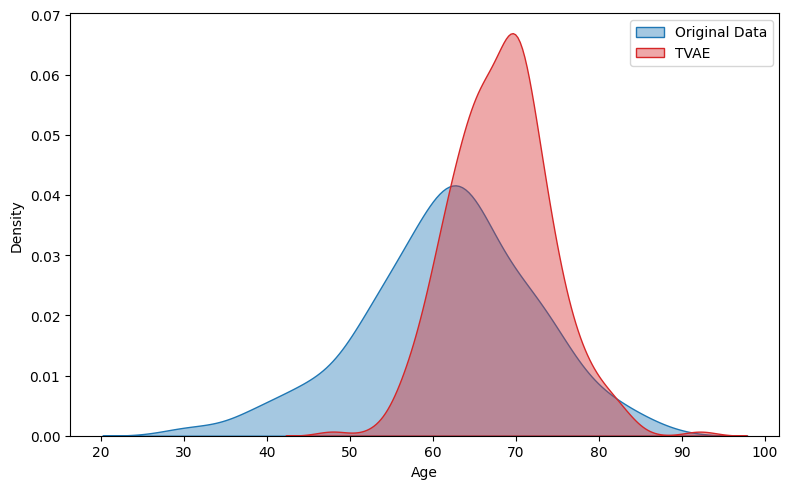

KS statistic: 0.3730, p-value: 1.205e-19


In [67]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

def plot_dual_kde_and_ks(sample1, sample2, label1='Sample 1', label2='Sample 2', color1='#1f77b4', color2='#d62728'):
    plt.figure(figsize=(8,5))
    sns.kdeplot(sample1, label=label1, color=color1, fill=True, alpha=0.4)
    sns.kdeplot(sample2, label=label2, color=color2, fill=True, alpha=0.4)
    plt.legend()
    plt.tight_layout()

    # KS test
    ks_stat, ks_pvalue = ks_2samp(sample1, sample2)
    plt.title('')

    plt.show()

    print(f"KS statistic: {ks_stat:.4f}, p-value: {ks_pvalue:.4g}")
    return ks_stat, ks_pvalue

# --- Example usage ---
if __name__ == "__main__":
    # Generate example data
    np.random.seed(0)
    a = dataset_dict['Origin']["Age"]
    b = dataset_dict['tvae_42']["Age"]
    plot_dual_kde_and_ks(a, b, label1="Original Data", label2="TVAE")

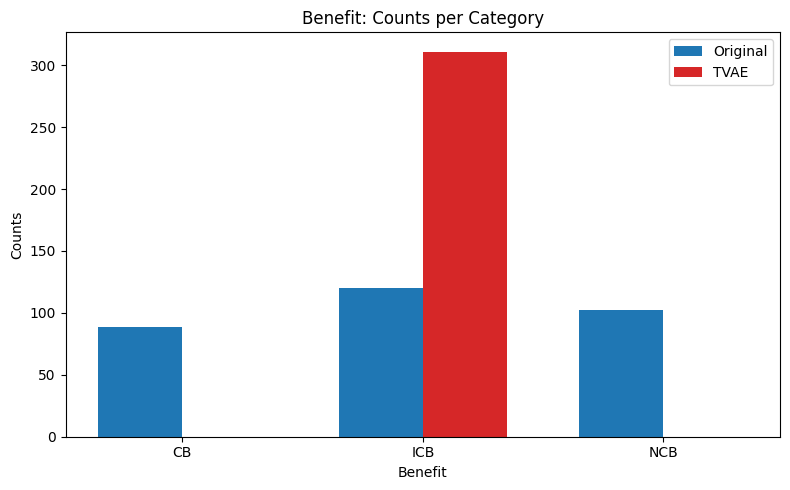

Total Variation Distance (TVD): 0.6141
     Original  TVAE  Original_proportion  Synthetic_proportion
CB         89     0             0.286174                   0.0
ICB       120   311             0.385852                   1.0
NCB       102     0             0.327974                   0.0
TVD: 0.6141479099678457


In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_categorical_bar_and_tvd(original, synthetic, categories=None, feature_name="categorical_feature"):
    """
    Draw a grouped bar plot for category counts in `original` and `synthetic` samples,
    and compute their Total Variation Distance (TVD).

    Parameters:
    - original: array-like of values, single feature from original data
    - synthetic: array-like of values, same feature from synthetic data
    - categories: list/array of category values; if None, union of values from both arrays
    - feature_name: str, name for display/title

    Returns:
    - tvd: float, total variation distance
    - df_counts: pd.DataFrame with counts and proportions per category for both sets
    """

    # Categorize
    original = pd.Series(original)
    synthetic = pd.Series(synthetic)
    if categories is None:
        categories = sorted(set(original.unique()).union(set(synthetic.unique())))
    
    # Counts and proportions
    orig_counts = original.value_counts().reindex(categories, fill_value=0)
    synth_counts = synthetic.value_counts().reindex(categories, fill_value=0)
    orig_probs = orig_counts / orig_counts.sum()
    synth_probs = synth_counts / synth_counts.sum()
    
    # DataFrame for plotting
    df_counts = pd.DataFrame({
        "Original": orig_counts,
        "TVAE": synth_counts,
        "Original_proportion": orig_probs,
        "Synthetic_proportion": synth_probs
    }, index=categories)
    
    # Bar plot
    fig, ax = plt.subplots(figsize=(8, 5))
    width = 0.35
    x = np.arange(len(categories))
    ax.bar(x - width/2, df_counts["Original"], width, label='Original', color='#1f77b4')
    ax.bar(x + width/2, df_counts["TVAE"], width, label='TVAE', color='#d62728')
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_xlabel(feature_name)
    ax.set_ylabel("Counts")
    ax.legend()
    plt.title(f'{feature_name}: Counts per Category')
    plt.tight_layout()
    plt.show()

    # TVD: 0.5 * sum(abs(p_i - q_i))
    tvd = 0.5 * np.sum(np.abs(orig_probs - synth_probs))
    print(f"Total Variation Distance (TVD): {tvd:.4f}")
    return tvd, df_counts

# --- Example usage ---
if __name__ == "__main__":
    # Toy data
    original = dataset_dict['Origin']["Benefit"]
    synthetic = dataset_dict['tvae_42']["Benefit"]
    tvd, df_cat = plot_categorical_bar_and_tvd(original, synthetic, feature_name="Benefit")
    print(df_cat)
    print("TVD:", tvd)

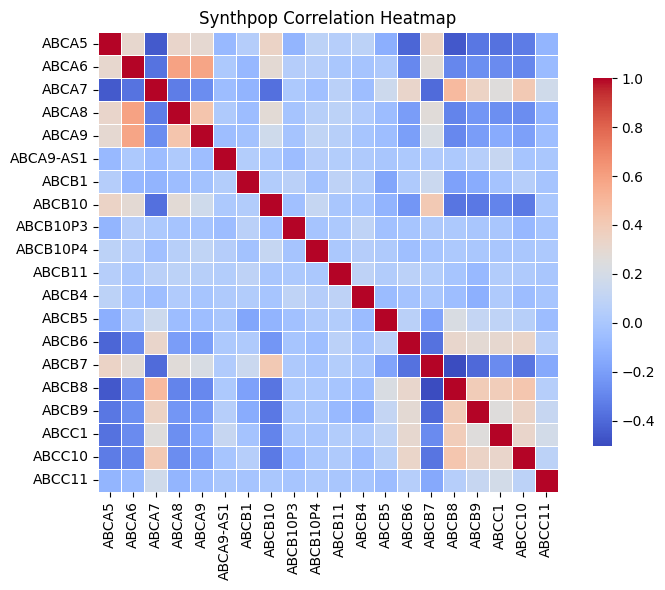

In [90]:
def plot_correlation_heatmap(data, figsize=(8,6), annot=False, cmap='coolwarm', title='Correlation Heatmap', savepath=None):
    """
    Draw a correlation heatmap for a pandas DataFrame.

    Parameters:
    - data: pandas DataFrame (numeric features)
    - figsize: tuple, size of the figure
    - annot: bool, whether to annotate each cell
    - cmap: str or matplotlib colormap, color map for heatmap
    - title: str, title for plot
    - savepath: str or None, if provided, plot will be saved to this path
    
    Returns:
    - corrmat: pandas DataFrame of correlations
    """

    corrmat = data.corr()
    plt.figure(figsize=figsize)
    ax = sns.heatmap(corrmat, annot=annot, cmap=cmap, square=True,
                     fmt='.2f', linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title(title)
    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()
    return corrmat

# --- Example usage ---
if __name__ == "__main__":
    # Make sample matrix
    df_t = symbols_dataset_dict["synthpop_42"].T
    df_t = pd.DataFrame(df_t.values[1:], columns=df_t.values[0], index =df_t.index[1:])
    plot_correlation_heatmap(df_t.iloc[:,50:70], title="Synthpop Correlation Heatmap")

In [20]:
df_t = symbols_dataset_dict['Origin'].T
df_t = pd.DataFrame(df_t.values[1:], columns=df_t.values[0], index =df_t.index[1:])
df_t.head()

,5S_rRNA,7SK,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2MP1,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
Patient_ID,,,,,,,,,,,,,,,,,,,,,
G138701_RCCBMS-00020-T_v1_RNA_OnPrem,21.038652,35.199603,30.187983,22.999432,33.643965,37.130851,22.705126,22.869853,21.076515,21.271282,...,33.26816,30.04056,30.36292,30.98129,32.38442,28.01561,31.24379,33.81903,33.22469,31.23383
G138701_RCCBMS-00097-T_v1_RNA_OnPrem,21.038652,38.183943,30.483638,25.581769,28.866645,37.945043,27.797609,24.1421,21.076515,21.271282,...,31.53633,29.94062,30.80829,30.74475,32.0947,26.32526,32.70057,33.67262,33.10198,32.44643
G138701_RCCBMS-00141-T_v1_RNA_OnPrem,21.038652,37.141292,30.092851,26.933385,26.684228,36.851946,22.705126,30.406352,21.076515,21.271282,...,30.74474,31.95812,30.73898,30.15898,31.69473,26.33098,32.6833,33.96047,32.97135,32.20607
G138701_RCCBMS-00099-T_v1_RNA_OnPrem,21.038652,36.447015,30.97501,26.683128,32.521494,38.453517,26.337846,28.229357,21.076515,21.271282,...,31.63196,30.71732,31.09654,30.25757,31.90774,27.53819,32.64194,34.54254,33.24885,32.78278
G138701_RCCBMS-00163-T_v1_RNA_OnPrem,21.038652,37.623923,26.91575,22.999432,23.219176,38.931987,22.705126,22.869853,21.076515,21.271282,...,31.7562,30.75149,30.55896,30.17101,31.01545,21.45312,32.8662,34.24375,34.8672,32.73361


In [15]:
Angio = ['VEGFA','KDR','ESM1','ANGPTL4','CD34']
Teff = ['CD8A','EOMES','PRF1','IFNG','CD274']
Myeloid = ['IL6', 'CXCL1', 'CXCL2', 'CXCL3', 'CXCL8', 'PTGS2']
Javelin = ['CD3G', 'CD3E', 'CD8B', 'THEMIS', 'TRAT1', 'GRAP2', 'CD247', 'CD2', 'CD96', 'PRF1', 'CD6', 'IL7R', 'ITK', 'GPR18', 'EOMES', 
           'SIT1', 'NLRC3', 'CD244', 'KLRD1', 'SH2D1A', 'XCL2', 'CST7', 'GFI1', 'KCNA3', 'PSTPIP1']
TIS = ['PSMB10', 'HLA-DQA1', 'HLA-DRB1', 'CMKLR1', 'HLA-E', 'NKG7', 'CD8A', 'CXCL9', 'CD27', 'CXCR6', 'IDO1', 
       'STAT1', 'TIGIT', 'LAG3', 'CD274', 'PDCD1LG2', 'CD276']

In [16]:
# Fig 2h - hierarchical clustering of genomic and transcriptomic features
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns
import matplotlib.pyplot as plt
fullDF = df_t

def cluster_features(data, method = "ward"):
    corrmat = data.corr()
    # 2. Replace NaN/infinite with 0 (or another value as needed)
    if corrmat.isnull().values.any() or np.isinf(corrmat.values).any():
        print("Warning: NaNs/Infs found in correlation matrix, filling with 0.")
        corrmat = corrmat.fillna(0)
        corrmat.replace([np.inf, -np.inf], 0, inplace=True)
    
    Z = linkage(corrmat, method=method)
    plt.ioff()

    dendrogram_output = dendrogram(
        Z, 
        leaf_rotation=90, 
        leaf_font_size=6
    )
    
    order = [int(s) for s in dendrogram_output['ivl']]
    plt.close()
    return Z, order, corrmat

comparators = list(set(Angio)|set(Teff)|set(Myeloid)|set(Javelin)|set(TIS))
comparator_df = fullDF[comparators]
Z,  order, corrmat = cluster_features(comparator_df, "ward")

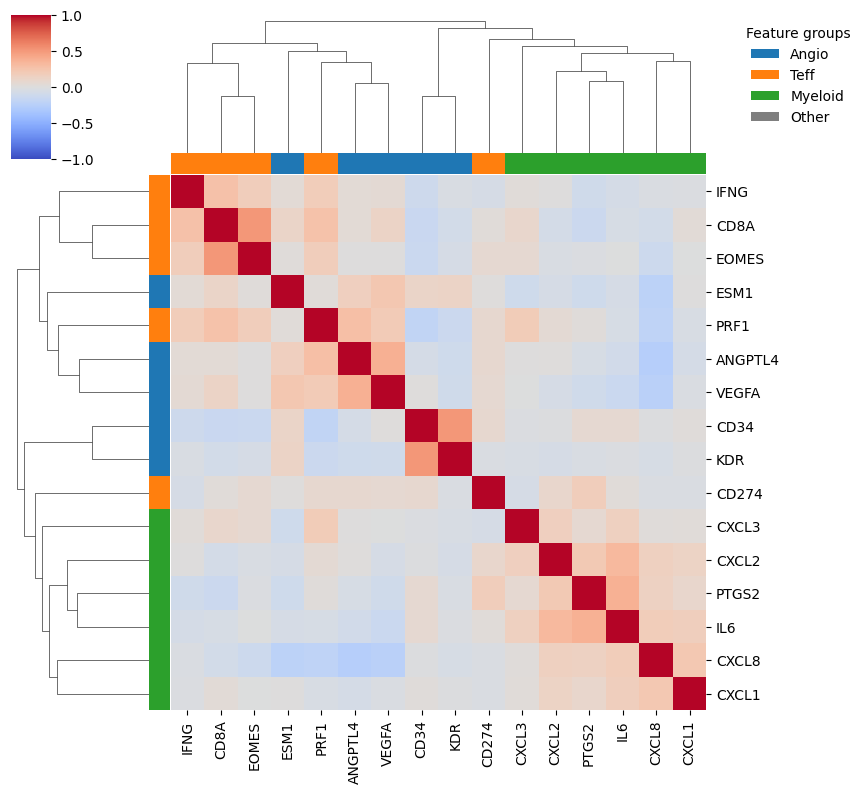

Used colors: {'Angio': '#1f77b4', 'Teff': '#ff7f0e', 'Myeloid': '#2ca02c', 'Other': '#7f7f7f'}


In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

def draw_clustermap(
    corrmatrix,
    order,
    feature_groups,
    color_map=None,
    palette="tab10",
    n_colors=5,
    figsize=(8, 8),
    filepath=None,
    cmap="coolwarm",
    show=True,
):


    # --- Validate and normalize order ---
    if len(order) != len(corrmatrix.index):
        raise ValueError(f"Length of 'order' ({len(order)}) does not match corrmatrix shape ({corrmatrix.shape})")

    # If order contains integers -> treat as positional indices
    if len(order) > 0 and isinstance(order[0], (int, np.integer)):
        ordered_features = corrmatrix.index[list(order)]
    else:
        # treat as feature name list; verify it matches corrmatrix.index content
        ordered_features = pd.Index(order)
        if set(ordered_features) != set(corrmatrix.index):
            raise ValueError("When 'order' is a list of names, it must contain exactly the same features as corrmatrix.index")

    # --- Prepare groups and colors ---
    groups = list(feature_groups.keys())

    # Ensure an 'Other' group exists for unmapped features
    if "Other" not in groups:
        groups = groups + ["Other"]

    # If user provided a color_map, copy it; otherwise create one
    final_color_map = {} if color_map is None else dict(color_map)

    # Determine how many colors to generate (at least one per group)
    required_colors = max(len(groups), n_colors)

    # Generate colors for groups that don't have a color yet
    generated_colors = sns.color_palette(palette, n_colors=required_colors)
    # Convert to hex strings using matplotlib (fixes seaborn.utils.hex_palette absence)
    generated_hex = [mcolors.to_hex(c) for c in generated_colors]

    gen_idx = 0
    for g in groups:
        if g in final_color_map:
            continue
        final_color_map[g] = generated_hex[gen_idx]
        gen_idx += 1
        # safety: wrap around if somehow required_colors < needed (shouldn't happen)
        if gen_idx >= len(generated_hex):
            gen_idx = 0

    # Ensure 'Other' has a color (fallback)
    if "Other" not in final_color_map:
        final_color_map["Other"] = "#d3d3d3"

    # --- Build color list per feature in the requested order ---
    col_colors = []
    for feat in ordered_features:
        assigned = False
        for fg, members in feature_groups.items():
            if feat in members:
                col_colors.append(final_color_map.get(fg, final_color_map["Other"]))
                assigned = True
                break
        if not assigned:
            col_colors.append(final_color_map["Other"])

    # --- Subset and align corrmatrix to ordered features ---
    corr_sub = corrmatrix.loc[ordered_features, ordered_features]

    # --- Plot clustermap ---
    cg = sns.clustermap(
        corr_sub,
        cmap=cmap,
        center=0,
        row_colors=col_colors,
        vmin = -1,
        vmax = 1,
        col_colors=col_colors,
        linewidths=0,
        figsize=figsize,
    )

    # Improve label rotation / font size
    plt.setp(cg.ax_heatmap.yaxis.get_majorticklabels(), rotation=0, fontsize=10)
    plt.setp(cg.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, fontsize=10)

    # --- Add legend for groups ---
    legend_groups = [g for g in groups if g in final_color_map]
    patches = [Patch(facecolor=final_color_map[g], edgecolor="none", label=g) for g in legend_groups]

    try:
        cg.ax_col_dendrogram.legend(
            handles=patches,
            title="Feature groups",
            bbox_to_anchor=(1.05, 1.0),
            loc="upper left",
            frameon=False,
        )
    except Exception:
        cg.ax_heatmap.legend(
            handles=patches,
            title="Feature groups",
            bbox_to_anchor=(1.05, 1.0),
            loc="upper left",
            frameon=False,
        )

    # --- Save / show ---
    if filepath:
        plt.savefig(filepath, dpi=300, bbox_inches="tight")
    if show:
        plt.show()

    return cg, final_color_map


# --- Usage example for 5 groups ---
if __name__ == "__main__":

    Angio = ['VEGFA','KDR','ESM1','ANGPTL4','CD34']
    Teff = ['CD8A','EOMES','PRF1','IFNG','CD274']
    Myeloid = ['IL6', 'CXCL1', 'CXCL2', 'CXCL3', 'CXCL8', 'PTGS2']
    # Javelin = ['CD3G', 'CD3E', 'CD8B', 'THEMIS', 'TRAT1', 'GRAP2', 'CD247', 'CD2', 'CD96', 'PRF1', 'CD6', 'IL7R', 'ITK', 'GPR18', 'EOMES', 
    #            'SIT1', 'NLRC3', 'CD244', 'KLRD1', 'SH2D1A', 'XCL2', 'CST7', 'GFI1', 'KCNA3', 'PSTPIP1']
    # TIS = ['PSMB10', 'HLA-DQA1', 'HLA-DRB1', 'CMKLR1', 'HLA-E', 'NKG7', 'CD8A', 'CXCL9', 'CD27', 'CXCR6', 'IDO1', 
    #        'STAT1', 'TIGIT', 'LAG3', 'CD274', 'PDCD1LG2', 'CD276']
    MHC1 = ['HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'TAP1', 'TAP2', 'B2M']
    MHC2 = [
    'HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1',
    'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1',
    'HLA-DRB5']
    # comparators = list(set(Angio)|set(Teff)|set(Myeloid)|set(MHC1)|set(MHC2))
    df_t = symbols_dataset_dict['synthpop_42'].T
    df_t = pd.DataFrame(df_t.values[1:], columns=df_t.values[0], index =df_t.index[1:])

    comparators = list(set(Angio)|set(Teff)|set(Myeloid))
    comparator_df = df_t[comparators]
    Z,  order, corrmat = cluster_features(comparator_df, "ward")
    feature_groups = {
        "Angio": Angio,
        "Teff": Teff,
        "Myeloid": Myeloid,
    #     "MHC1": ['HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'TAP1', 'TAP2', 'B2M'],
    #     "MHC2": [
    # 'HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1',
    # 'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1',
    # 'HLA-DRB5']
    }

    # Option A: provide your own 5-color map
    color_map = {
        "Angio":  "#1f77b4",  # blue
        "Teff":   "#ff7f0e",  # orange
        "Myeloid":"#2ca02c",  # green
        # "MHC1":   "#d62728",  # red
        # "MHC2":   "#9467bd",  # purple
        "Other":  "#7f7f7f",  # gray (6th / fallback)
    }

    cg, used_colors = draw_clustermap(
        corrmatrix=corrmat,
        order=order,
        feature_groups=feature_groups,
        color_map=color_map,
        figsize=(8, 8),
        filepath=None,
    )
    print("Used colors:", used_colors)

In [150]:
angio_df = symbols_dataset_dict['Origin'][symbols_dataset_dict['synthpop_42']['Gene'].isin(Angio)]
angio_df_mean = angio_df.iloc[:,1:].mean(axis = 0)

In [178]:
from scipy.stats import ranksums
dataset = 'tvae_42'
Angio = ['VEGFA','KDR','ESM1','ANGPTL4','CD34']
metadata = dataset_dict[dataset]['PBRM1']
wt_sample = metadata[metadata == 'WT'].index.tolist()
mut_sample = metadata[metadata == 'MUT'].index.tolist()
angio_df = symbols_dataset_dict[dataset][symbols_dataset_dict[dataset]['Gene'].isin(Angio)]
angio_df_mean = angio_df.iloc[:,1:].mean(axis = 0)

mut_angio = angio_df_mean.loc[mut_sample].values.tolist()
wt_angio = angio_df_mean.loc[wt_sample].values.tolist()

log2fc = np.log2(np.mean(mut_angio)/np.mean(wt_angio))

statistic, p_value = ranksums(mut_angio, wt_angio) 
print(p_value)

nan


/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/scipy/stats/_stats_py.py:9154: RuntimeWarning: invalid value encountered in double_scalars
  z = (s - expected) / np.sqrt(n1*n2*(n1+n2+1)/12.0)


/tmp/ipykernel_458701/2633540342.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


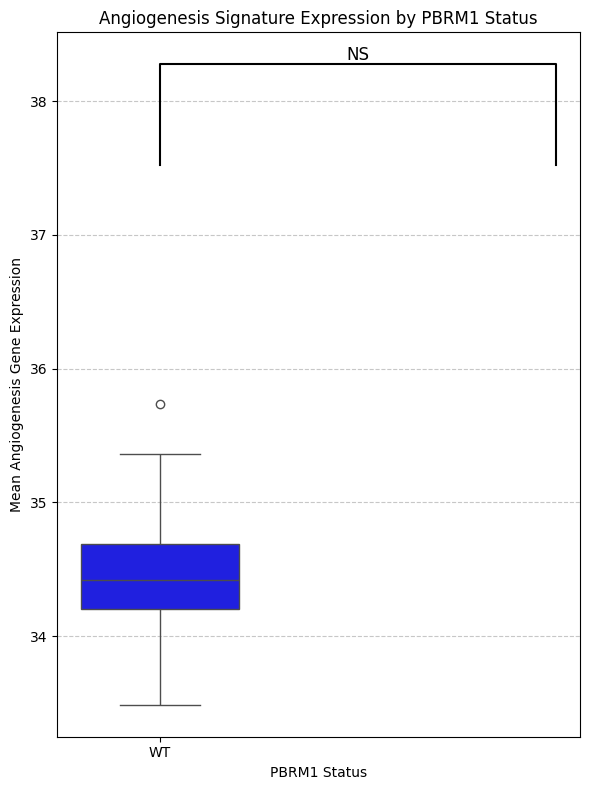

In [179]:
data_for_plot = pd.DataFrame({
    'Expression_Mean': mut_angio + wt_angio,
    'PBRM1_Status': ['MUT'] * len(mut_angio) + ['WT'] * len(wt_angio)
})

# --- 3. Plotting the Boxplots ---

plt.figure(figsize=(6, 8))
# Create the boxplot using seaborn
sns.boxplot(
    x='PBRM1_Status',  # The categorical variable for the x-axis
    y='Expression_Mean', # The numerical data for the y-axis
    data=data_for_plot,
    palette={'MUT': 'red', 'WT': 'blue'}, # Define colors
    width=0.4
)



# --- 4. Annotating the P-value ---

# Define the coordinates for the annotation
# We'll place the p-value above the boxes.
# Find the maximum expression value to determine the annotation height
max_expression = data_for_plot['Expression_Mean'].max()
y_coord = max_expression + 0.05 * max_expression # Place it slightly above the max

# Draw a line connecting the two groups for visual context of the comparison
# x=0 for MUT, x=1 for WT
plt.plot([0, 0, 1, 1],
         [y_coord, y_coord * 1.02, y_coord * 1.02, y_coord], # Draw a bracket-like line
         lw=1.5,
         c='k')

# Format the p-value string
if p_value < 0.001:
    p_value_string = f'p-value < 0.001' # Use scientific notation for clarity
elif 0.001 < p_value and p_value<0.01:
    p_value_string = f'p-value < 0.01'
elif 0.01 < p_value and p_value<0.05:
    p_value_string = f'p-value < 0.05'
else:
    p_value_string = 'NS'

# Add the text annotation (centered above the line)
plt.text(
    x=0.5, # Center the text between the two boxes (0 and 1)
    y=y_coord * 1.02,
    s=p_value_string,
    ha='center', # Horizontal alignment
    va='bottom', # Vertical alignment
    fontsize=12
)

# --- 5. Customizing Labels and Title ---

plt.title('Angiogenesis Signature Expression by PBRM1 Status')
plt.xlabel('PBRM1 Status')
plt.ylabel('Mean Angiogenesis Gene Expression')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust plot to prevent labels from being cut off
plt.show()

In [158]:
p_value < 0.001

True

P-value from ranksums test: 0.0550


/tmp/ipykernel_458701/2796822936.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


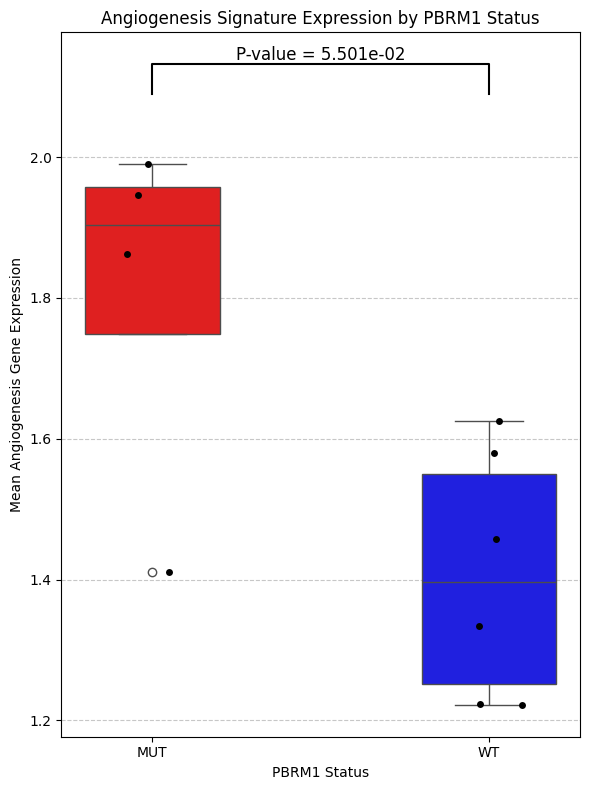

In [132]:
import numpy as np
import pandas as pd
from scipy.stats import ranksums
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Data Setup (Based on your provided context) ---

# Mock-up data structures to make the code executable
# Replace these with your actual loaded data: dataset_dict, symbols_dataset_dict, Angio

# Example setup for dataset_dict['Origin']['PBRM1']
metadata = pd.Series(
    ['WT', 'MUT', 'WT', 'WT', 'MUT', 'WT', 'MUT', 'WT', 'MUT', 'WT'],
    index=[f'Sample_{i}' for i in range(10)],
    name='PBRM1'
)
wt_sample = metadata[metadata == 'WT'].index.tolist()
mut_sample = metadata[metadata == 'MUT'].index.tolist()

# Example setup for symbols_dataset_dict
# 'Gene' column for filtering and expression data for mean calculation
Angio = ['GeneA', 'GeneB', 'GeneC'] # Example list of Angiogenesis genes
data = {
    'Gene': ['GeneA', 'GeneB', 'GeneC', 'GeneD', 'GeneE'],
    'Sample_0': np.random.rand(5) + 1,
    'Sample_1': np.random.rand(5) + 1,
    'Sample_2': np.random.rand(5) + 1,
    'Sample_3': np.random.rand(5) + 1,
    'Sample_4': np.random.rand(5) + 1.5,
    'Sample_5': np.random.rand(5) + 1,
    'Sample_6': np.random.rand(5) + 1.5,
    'Sample_7': np.random.rand(5) + 1,
    'Sample_8': np.random.rand(5) + 1.5,
    'Sample_9': np.random.rand(5) + 1
}
angio_df = pd.DataFrame(data)
angio_df = angio_df[angio_df['Gene'].isin(Angio)]

# Calculate mean expression across Angiogenesis genes for each sample
angio_df_mean = angio_df.iloc[:, 1:].mean(axis=0)

# Separate mean expression values for MUT and WT samples
mut_angio = angio_df_mean.loc[mut_sample].values.tolist()
wt_angio = angio_df_mean.loc[wt_sample].values.tolist()

# Perform the ranksums test
statistic, p_value = ranksums(mut_angio, wt_angio)
print(f"P-value from ranksums test: {p_value:.4f}")

# --- 2. Data Formatting for Plotting ---

# Create a DataFrame suitable for seaborn plotting
# This is the easiest way to manage groups for boxplots/violins
data_for_plot = pd.DataFrame({
    'Expression_Mean': mut_angio + wt_angio,
    'PBRM1_Status': ['MUT'] * len(mut_angio) + ['WT'] * len(wt_angio)
})

# --- 3. Plotting the Boxplots ---

plt.figure(figsize=(6, 8))
# Create the boxplot using seaborn
sns.boxplot(
    x='PBRM1_Status',  # The categorical variable for the x-axis
    y='Expression_Mean', # The numerical data for the y-axis
    data=data_for_plot,
    palette={'MUT': 'red', 'WT': 'blue'}, # Define colors
    width=0.4
)

# Add individual data points (swarmplot or stripplot) for better visualization
sns.stripplot(
    x='PBRM1_Status',
    y='Expression_Mean',
    data=data_for_plot,
    color='black',
    size=5,
    jitter=True
)

# --- 4. Annotating the P-value ---

# Define the coordinates for the annotation
# We'll place the p-value above the boxes.
# Find the maximum expression value to determine the annotation height
max_expression = data_for_plot['Expression_Mean'].max()
y_coord = max_expression + 0.05 * max_expression # Place it slightly above the max

# Draw a line connecting the two groups for visual context of the comparison
# x=0 for MUT, x=1 for WT
plt.plot([0, 0, 1, 1],
         [y_coord, y_coord * 1.02, y_coord * 1.02, y_coord], # Draw a bracket-like line
         lw=1.5,
         c='k')

# Format the p-value string
p_value_string = f'P-value = {p_value:.3e}' # Use scientific notation for clarity

# Add the text annotation (centered above the line)
plt.text(
    x=0.5, # Center the text between the two boxes (0 and 1)
    y=y_coord * 1.02,
    s=p_value_string,
    ha='center', # Horizontal alignment
    va='bottom', # Vertical alignment
    fontsize=12
)

# --- 5. Customizing Labels and Title ---

plt.title('Angiogenesis Signature Expression by PBRM1 Status')
plt.xlabel('PBRM1 Status')
plt.ylabel('Mean Angiogenesis Gene Expression')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust plot to prevent labels from being cut off
plt.show()

In [49]:
Angio = ['VEGFA','KDR','ESM1','ANGPTL4','CD34']
Teff = ['CD8A','EOMES','PRF1','IFNG','CD274']
Myeloid = ['IL6', 'CXCL1', 'CXCL2', 'CXCL3', 'CXCL8', 'PTGS2']
# Javelin = ['CD3G', 'CD3E', 'CD8B', 'THEMIS', 'TRAT1', 'GRAP2', 'CD247', 'CD2', 'CD96', 'PRF1', 'CD6', 'IL7R', 'ITK', 'GPR18', 'EOMES', 
#            'SIT1', 'NLRC3', 'CD244', 'KLRD1', 'SH2D1A', 'XCL2', 'CST7', 'GFI1', 'KCNA3', 'PSTPIP1']
# TIS = ['PSMB10', 'HLA-DQA1', 'HLA-DRB1', 'CMKLR1', 'HLA-E', 'NKG7', 'CD8A', 'CXCL9', 'CD27', 'CXCR6', 'IDO1', 
#        'STAT1', 'TIGIT', 'LAG3', 'CD274', 'PDCD1LG2', 'CD276']
MHC1 = ['HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'TAP1', 'TAP2', 'B2M']
MHC2 = [
'HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1',
'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1',
'HLA-DRB5']
# comparators = list(set(Angio)|set(Teff)|set(Myeloid)|set(MHC1)|set(MHC2))
df_t = symbols_dataset_dict['synthpop_42'].T
df_t = pd.DataFrame(df_t.values[1:], columns=df_t.values[0], index =df_t.index[1:])

# comparators = list(set(Angio)|set(Teff)|set(Myeloid))
comparator_df = df_t[comparators]
corrmat_syn = comparator_df.corr('spearman')

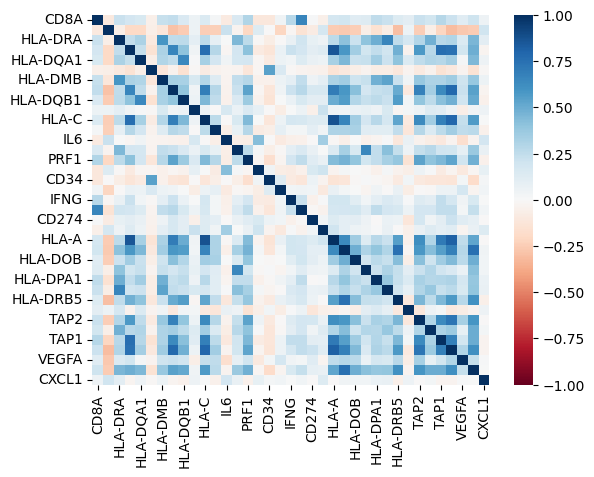

In [50]:
fig = sns.heatmap(corrmat_syn,vmin=-1.0, cmap='RdBu', # Set the minimum value for the color bar gradient
            vmax=1.0)
plt.show()

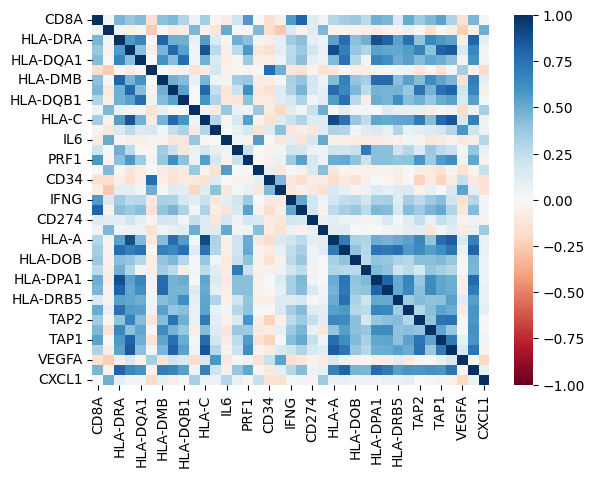

In [51]:
Angio = ['VEGFA','KDR','ESM1','ANGPTL4','CD34']
Teff = ['CD8A','EOMES','PRF1','IFNG','CD274']
Myeloid = ['IL6', 'CXCL1', 'CXCL2', 'CXCL3', 'CXCL8', 'PTGS2']
# Javelin = ['CD3G', 'CD3E', 'CD8B', 'THEMIS', 'TRAT1', 'GRAP2', 'CD247', 'CD2', 'CD96', 'PRF1', 'CD6', 'IL7R', 'ITK', 'GPR18', 'EOMES', 
#            'SIT1', 'NLRC3', 'CD244', 'KLRD1', 'SH2D1A', 'XCL2', 'CST7', 'GFI1', 'KCNA3', 'PSTPIP1']
# TIS = ['PSMB10', 'HLA-DQA1', 'HLA-DRB1', 'CMKLR1', 'HLA-E', 'NKG7', 'CD8A', 'CXCL9', 'CD27', 'CXCR6', 'IDO1', 
#        'STAT1', 'TIGIT', 'LAG3', 'CD274', 'PDCD1LG2', 'CD276']
MHC1 = ['HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'TAP1', 'TAP2', 'B2M']
MHC2 = [
'HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1',
'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1',
'HLA-DRB5']
comparators = list(set(Angio)|set(Teff)|set(Myeloid)|set(MHC1)|set(MHC2))
df_t = symbols_dataset_dict['Origin'].T
df_t = pd.DataFrame(df_t.values[1:], columns=df_t.values[0], index =df_t.index[1:])

# comparators = list(set(Angio)|set(Teff)|set(Myeloid))
comparator_df = df_t[comparators]
corrmat_or = comparator_df.corr('spearman')
fig_or = sns.heatmap(corrmat_or,vmin=-1.0,cmap='RdBu',  # Set the minimum value for the color bar gradient
            vmax=1.0,)
plt.show()

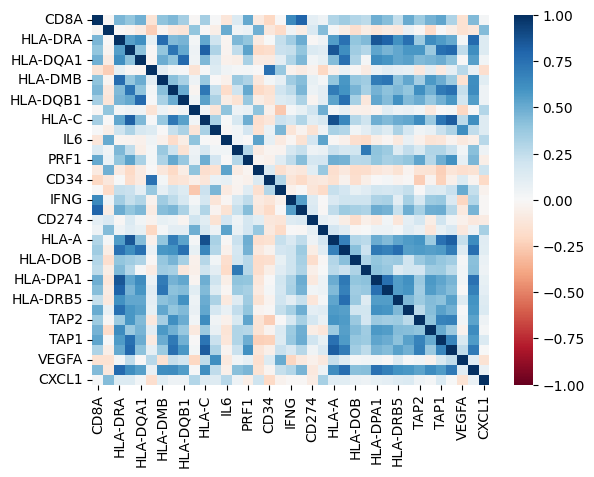

In [52]:
Angio = ['VEGFA','KDR','ESM1','ANGPTL4','CD34']
Teff = ['CD8A','EOMES','PRF1','IFNG','CD274']
Myeloid = ['IL6', 'CXCL1', 'CXCL2', 'CXCL3', 'CXCL8', 'PTGS2']
# Javelin = ['CD3G', 'CD3E', 'CD8B', 'THEMIS', 'TRAT1', 'GRAP2', 'CD247', 'CD2', 'CD96', 'PRF1', 'CD6', 'IL7R', 'ITK', 'GPR18', 'EOMES', 
#            'SIT1', 'NLRC3', 'CD244', 'KLRD1', 'SH2D1A', 'XCL2', 'CST7', 'GFI1', 'KCNA3', 'PSTPIP1']
# TIS = ['PSMB10', 'HLA-DQA1', 'HLA-DRB1', 'CMKLR1', 'HLA-E', 'NKG7', 'CD8A', 'CXCL9', 'CD27', 'CXCR6', 'IDO1', 
#        'STAT1', 'TIGIT', 'LAG3', 'CD274', 'PDCD1LG2', 'CD276']
MHC1 = ['HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'TAP1', 'TAP2', 'B2M']
MHC2 = [
'HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1',
'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1',
'HLA-DRB5']
comparators = list(set(Angio)|set(Teff)|set(Myeloid)|set(MHC1)|set(MHC2))
df_t = symbols_dataset_dict['gaussiancopula_42'].T
df_t = pd.DataFrame(df_t.values[1:], columns=df_t.values[0], index =df_t.index[1:])

# comparators = list(set(Angio)|set(Teff)|set(Myeloid))
comparator_df = df_t[comparators]
corrmat_gc = comparator_df.corr('spearman')
fig_gc = sns.heatmap(corrmat_gc,vmin=-1.0,cmap='RdBu',  # Set the minimum value for the color bar gradient
            vmax=1.0,)
plt.show()

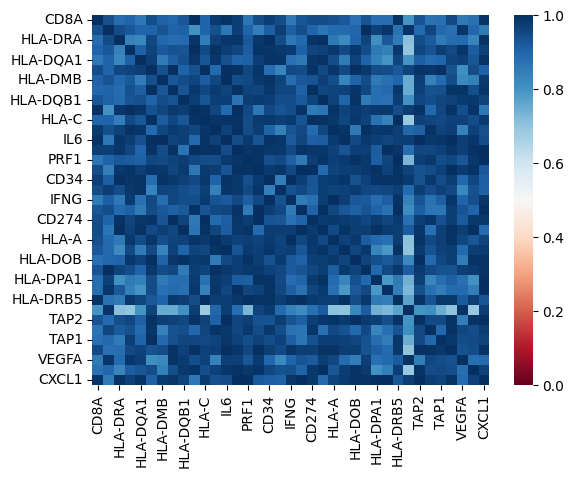

In [53]:
syn_dif_mat = 1 - 1/2*np.abs((corrmat_or - corrmat_syn))
gc_dif_mat = 1 - 1/2*np.abs((corrmat_or - corrmat_gc))

fig_syn_df = sns.heatmap(syn_dif_mat,vmin=0,cmap='RdBu',  # Set the minimum value for the color bar gradient
            vmax=1.0,)
plt.show()

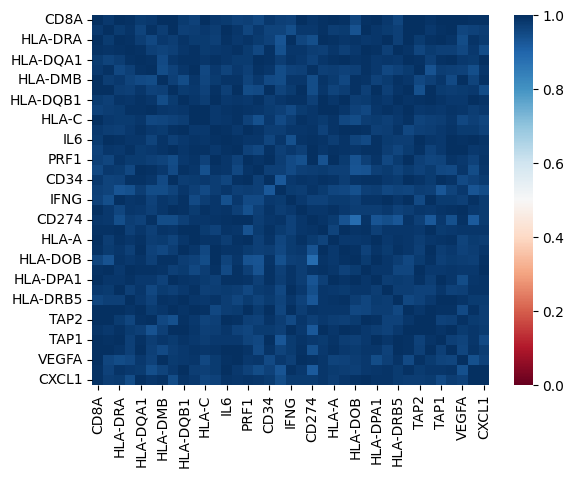

In [54]:
fig_gc_df = sns.heatmap(gc_dif_mat,vmin=0,cmap='RdBu',  # Set the minimum value for the color bar gradient
            vmax=1.0,)
plt.show()

In [73]:
# 1. Create the Boolean Mask (a DataFrame of True/False values)
# The result of this comparison is a DataFrame with the same shape as corrmat_or,
# containing True where the value is >= 0.5, and False otherwise.
boolean_mask = corrmat_or >= 0.5

# 2. Use the Boolean Mask to filter the target DataFrame (gc_dif_mat)
# This operation returns a pandas Series containing all values from gc_dif_mat
# where the corresponding entry in boolean_mask is True.
high_correlation_differences = gc_dif_mat[boolean_mask].stack().dropna()
np.mean(high_correlation_differences.values)

0.9833402227789428

In [74]:
# 1. Create the Boolean Mask (a DataFrame of True/False values)
# The result of this comparison is a DataFrame with the same shape as corrmat_or,
# containing True where the value is >= 0.5, and False otherwise.
boolean_mask = corrmat_or >= 0.5

# 2. Use the Boolean Mask to filter the target DataFrame (gc_dif_mat)
# This operation returns a pandas Series containing all values from gc_dif_mat
# where the corresponding entry in boolean_mask is True.
high_correlation_differences = syn_dif_mat[boolean_mask].stack().dropna()
np.mean(high_correlation_differences.values)

0.9091152806528868

In [56]:
np.mean(gc_dif_mat)

0.9793789012708035

In [57]:
np.mean(syn_dif_mat)

0.9387713075176881

In [246]:
from numba import njit, prange
parent_path = '/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline'
sys.path.append(parent_path)
from SynOmics.processing.metadata import MetaData
Angio = ['VEGFA','KDR','ESM1','ANGPTL4','CD34']
Teff = ['CD8A','EOMES','PRF1','IFNG','CD274']
Myeloid = ['IL6', 'CXCL1', 'CXCL2', 'CXCL3', 'CXCL8', 'PTGS2']
Javelin = ['CD3G', 'CD3E', 'CD8B', 'THEMIS', 'TRAT1', 'GRAP2', 'CD247', 'CD2', 'CD96', 'PRF1', 'CD6', 'IL7R', 'ITK', 'GPR18', 'EOMES', 
           'SIT1', 'NLRC3', 'CD244', 'KLRD1', 'SH2D1A', 'XCL2', 'CST7', 'GFI1', 'KCNA3', 'PSTPIP1']
TIS = ['PSMB10', 'HLA-DQA1', 'HLA-DRB1', 'CMKLR1', 'HLA-E', 'NKG7', 'CD8A', 'CXCL9', 'CD27', 'CXCR6', 'IDO1', 
       'STAT1', 'TIGIT', 'LAG3', 'CD274', 'PDCD1LG2', 'CD276']
MHC1 = ['HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'TAP1', 'TAP2', 'B2M']
MHC2 = [
'HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1',
'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1',
'HLA-DRB5']
comparators = list(set(Angio)|set(Teff)|set(Myeloid)|set(MHC1)|set(MHC2)|set(Javelin)|set(TIS))

or_df = symbols_dataset_dict['Origin'].T
or_df = pd.DataFrame(or_df.values[1:], columns=or_df.values[0], index =or_df.index[1:])
or_df = or_df[comparators]
# or_df = or_df.iloc[:,500:1500]
# metadata = MetaData.load(metadata_path)

syn_df = symbols_dataset_dict['gaussiancopula_42'].T
syn_df = pd.DataFrame(syn_df.values[1:], columns=syn_df.values[0], index =syn_df.index[1:])
syn_df = syn_df[comparators]
# syn_df = syn_df.iloc[:,500:1500]

synpop_df = symbols_dataset_dict['synthpop_42'].T
synpop_df = pd.DataFrame(synpop_df.values[1:], columns=synpop_df.values[0], index =synpop_df.index[1:])
synpop_df = synpop_df[comparators]
# synpop_df = synpop_df.iloc[:,500:1500]

In [247]:
from SynOmics.utils.correlations import MixedCorrelation
from SynOmics.utils.monitoring import monitor_resources

    # clean_metadata = MetaData.grouping_features_astype(processed_df, metadata)
cat_indices = MetaData.get_column_indices(or_df, [])
num_indices = MetaData.get_column_indices(or_df, or_df.columns.tolist())

compute_correlations = MixedCorrelation(cat_indices, num_indices, 
                                              method = "spearman", 
                                              n_bins = 10,
                                            engine = "auto",
                                            block_cols = 512
                                             )

corr_matrix_or = compute_correlations.compute(or_df)
                                             
corr_matrix_syn = compute_correlations.compute(syn_df)

corr_matrix_synpop = compute_correlations.compute(synpop_df)

syn_dif_mat = 1 - 1/2*np.abs(corr_matrix_or-corr_matrix_syn)
dif_mat = corr_matrix_syn-corr_matrix_or
difpop =  corr_matrix_synpop-corr_matrix_or
synthpop_dif_mat = 1 - 1/2*np.abs(corr_matrix_or-corr_matrix_synpop)
# containing True where the value is >= 0.5, and False otherwise.
boolean_mask = (corr_matrix_or) >= 0.5
high_correlation_differences = syn_dif_mat[boolean_mask]
high_correlation_differences_synthpop = synthpop_dif_mat[boolean_mask]
print('GC:', np.mean(high_correlation_differences))
print('Synthpop:',np.mean(high_correlation_differences_synthpop))

GC: 0.981099995568535
Synthpop: 0.8873350207272696


In [248]:
boolean_mask = (corr_matrix_or) <= -0.3
high_correlation_differences = syn_dif_mat[boolean_mask]
high_correlation_differences_synthpop = synthpop_dif_mat[boolean_mask]
print('GC:', np.mean(high_correlation_differences))
print('Synthpop:',np.mean(high_correlation_differences_synthpop))

GC: 0.9747592378884223
Synthpop: 0.9573731141970875


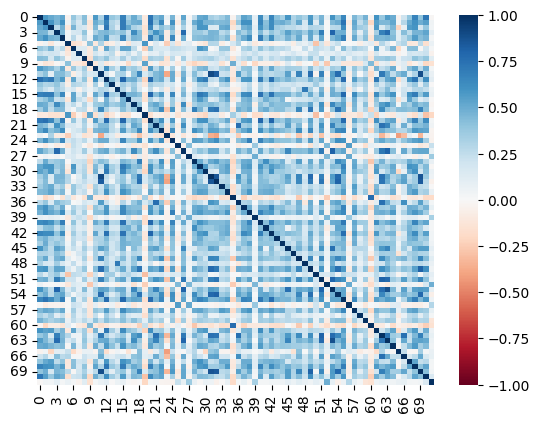

In [249]:
# plt.figure(figsize=(12, 10))
fig_or = sns.heatmap(corr_matrix_or,vmin=-1.0,cmap='RdBu',  # Set the minimum value for the color bar gradient
            vmax=1.0,)
plt.show()

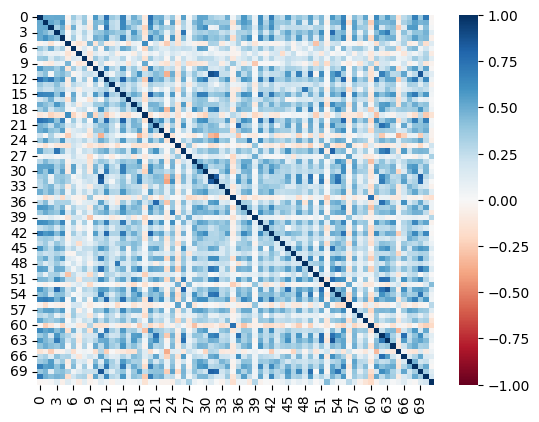

In [250]:
# plt.figure(figsize=(12, 10))
fig_gc = sns.heatmap(corr_matrix_syn,vmin=-1.0,cmap='RdBu',  # Set the minimum value for the color bar gradient
            vmax=1.0,)
plt.show()

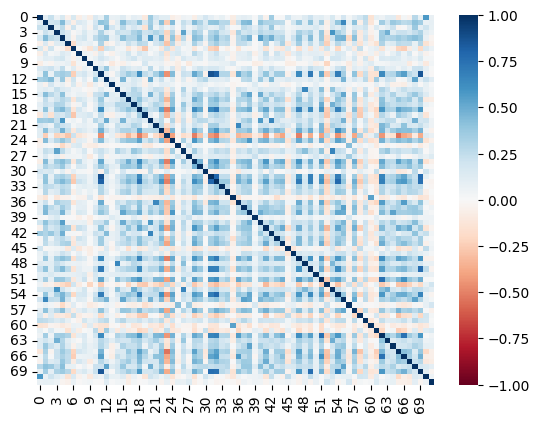

In [251]:
# plt.figure(figsize=(12, 10))
fig_pop = sns.heatmap(corr_matrix_synpop,vmin=-1.0,cmap='RdBu',  # Set the minimum value for the color bar gradient
            vmax=1.0,)
plt.show()